# 1. Install Dependencies

In [1]:
!pip install numpy pandas scikit-learn lightgbm shap matplotlib seaborn joblib


# 2. Importing Libraries & Setup

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import shap
import joblib
import warnings
shap.initjs()

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


# 3. Simulate Telecom-Style Churn Dataset

In [3]:
def simulate_churn_data(n_customers=20000, seed=RANDOM_SEED):
    rng = np.random.RandomState(seed)
    df = pd.DataFrame()

    df['customer_id'] = np.arange(1, n_customers + 1)
    df['age'] = rng.randint(18, 80, size=n_customers)
    df['gender'] = rng.choice(['Male', 'Female'], size=n_customers, p=[0.48, 0.52])

    df['tenure_months'] = rng.exponential(scale=24, size=n_customers).astype(int)
    df['monthly_charges'] = np.round(np.clip(rng.normal(loc=60, scale=20, size=n_customers), 10, 200), 2)
    df['num_services'] = rng.choice([1,2,3,4], size=n_customers, p=[0.2,0.4,0.3,0.1])

    df['contract_type'] = rng.choice(
        ['Month-to-month', 'One year', 'Two year'],
        size=n_customers, p=[0.55, 0.30, 0.15]
    )
    df['payment_method'] = rng.choice(
        ['Electronic check','Mailed check','Bank transfer','Credit card'],
        size=n_customers, p=[0.4,0.2,0.25,0.15]
    )

    df['avg_call_duration'] = np.round(np.clip(
        rng.normal(loc=8, scale=4, size=n_customers), 0.2, 60), 2)
    df['num_complaints'] = rng.poisson(lam=0.25, size=n_customers)
    df['num_support_tickets'] = rng.poisson(lam=0.3, size=n_customers)
    df['num_late_payments'] = rng.binomial(n=3, p=0.08, size=n_customers)

    df['total_charges'] = np.round(df['monthly_charges'] *
                                   (df['tenure_months'] + 1) *
                                   (0.9 + 0.2*rng.rand(n_customers)), 2)

    # add missing values
    for col in ['avg_call_duration', 'payment_method']:
        mask = rng.rand(n_customers) < 0.02
        df.loc[mask, col] = np.nan

    # churn generation function
    linear = (
        -0.04 * df['tenure_months'] +
        0.8 * (df['contract_type'] == 'Month-to-month').astype(int) +
        0.02 * df['monthly_charges'] +
        0.7 * (df['payment_method'] == 'Electronic check').astype(int) +
        0.9 * (df['num_complaints'] > 0).astype(int) +
        0.6 * df['num_late_payments']
    )

    prob = 1 / (1 + np.exp(-(-3.0 + linear)))
    df['churn_prob'] = prob
    df['churn'] = (rng.rand(n_customers) < prob).astype(int)

    return df

df = simulate_churn_data()
df.to_csv("data/simulated_churn.csv", index=False)
df.head()


,customer_id,age,gender,tenure_months,monthly_charges,num_services,contract_type,payment_method,avg_call_duration,num_complaints,num_support_tickets,num_late_payments,total_charges,churn_prob,churn
0,1,56,Female,15,45.16,1,Month-to-month,Credit card,11.43,0,0,1,670.90,0.214704,0
1,2,69,Male,62,54.80,1,Month-to-month,Electronic check,10.76,0,2,1,3219.23,0.092457,0
2,3,46,Female,29,64.33,2,Two year,Electronic check,11.91,0,0,0,1889.66,0.102165,0
3,4,32,Male,66,55.70,4,Month-to-month,Electronic check,11.78,2,1,0,3909.28,0.106595,0
4,5,60,Female,25,56.99,1,One year,Mailed check,9.30,0,0,0,1476.85,0.054156,0


# 4. Feature Engineering

In [4]:
df_fe = df.copy()

df_fe['tenure_bucket'] = pd.cut(
    df_fe['tenure_months'],
    bins=[-1,1,6,12,24,999],
    labels=['<1m','1-6m','6-12m','1-2y','>2y']
)

df_fe['spend_per_service'] = df_fe['monthly_charges'] / df_fe['num_services']
df_fe['high_charge_low_tenure'] = (
    (df_fe['monthly_charges'] > df_fe['monthly_charges'].median()) &
    (df_fe['tenure_months'] < 6)
).astype(int)

df_fe['tenure_months_safe'] = df_fe['tenure_months'].replace(0, 1)
df_fe['tickets_per_month'] = df_fe['num_support_tickets'] / df_fe['tenure_months_safe']

df_fe['payment_risk'] = df_fe['num_late_payments'] + \
                        (df_fe['payment_method'] == 'Electronic check').astype(int)
df_fe['had_complaint'] = (df_fe['num_complaints'] > 0).astype(int)

df_fe['contract_length_months'] = df_fe['contract_type'].map({
    'Month-to-month':1, 'One year':12, 'Two year':24
})

# handle missing values
df_fe['avg_call_duration'].fillna(df_fe['avg_call_duration'].median(), inplace=True)
df_fe['payment_method'].fillna(df_fe['payment_method'].mode()[0], inplace=True)

# label encode
le = LabelEncoder()
for c in ['gender','contract_type','payment_method','tenure_bucket']:
    df_fe[c + "_enc"] = le.fit_transform(df_fe[c].astype(str))

df_fe.head()


,customer_id,age,gender,tenure_months,monthly_charges,num_services,contract_type,payment_method,avg_call_duration,num_complaints,...,high_charge_low_tenure,tenure_months_safe,tickets_per_month,payment_risk,had_complaint,contract_length_months,gender_enc,contract_type_enc,payment_method_enc,tenure_bucket_enc
0,1,56,Female,15,45.16,1,Month-to-month,Credit card,11.43,0,...,0,15,0.000000,1,0,1,0,0,1,0
1,2,69,Male,62,54.80,1,Month-to-month,Electronic check,10.76,0,...,0,62,0.032258,2,0,1,1,0,2,4
2,3,46,Female,29,64.33,2,Two year,Electronic check,11.91,0,...,0,29,0.000000,1,0,24,0,2,2,4
3,4,32,Male,66,55.70,4,Month-to-month,Electronic check,11.78,2,...,0,66,0.015152,1,1,1,1,0,2,4
4,5,60,Female,25,56.99,1,One year,Mailed check,9.30,0,...,0,25,0.000000,0,0,12,0,1,3,4


# 5. Prepare Train/Test Split

In [5]:
feature_cols = [
    'age','gender_enc','tenure_months','tenure_bucket_enc','monthly_charges',
    'num_services','contract_length_months','avg_call_duration','num_complaints',
    'num_support_tickets','num_late_payments','total_charges','spend_per_service',
    'high_charge_low_tenure','tickets_per_month','payment_risk','had_complaint'
]

X = df_fe[feature_cols]
y = df_fe['churn']

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_fe['customer_id'], test_size=0.25, stratify=y, random_state=RANDOM_SEED
)

X_train.shape, X_test.shape


((15000, 17), (5000, 17))

# 6. Train LightGBM with Hyperparameter Search

In [6]:
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

param_dist = {
    'n_estimators':[100,200,400],
    'num_leaves':[15,31,63],
    'learning_rate':[0.01, 0.05, 0.1],
    'min_child_samples':[10,30,50],
    'subsample':[0.6,0.8,1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

rs = RandomizedSearchCV(
    lgb_model, param_distributions=param_dist, n_iter=12,
    scoring='roc_auc', cv=cv, random_state=RANDOM_SEED, verbose=1
)

rs.fit(X_train, y_train)
best_model = rs.best_estimator_

best_model


Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Number of positive: 2108, number of negative: 7892
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1376
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.210800 -> initscore=-1.320110
[LightGBM] [Info] Start training from score -1.320110
[LightGBM] [Info] Number of positive: 2107, number of negative: 7893
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1378
[LightGBM] [Info] Number of data points in the train s

LGBMClassifier(learning_rate=0.01, min_child_samples=30, n_estimators=400,
               n_jobs=-1, num_leaves=15, objective='binary', random_state=42,
               subsample=0.6)

# 7. Evaluate Model Performance

In [14]:
y_pred_proba = best_model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_pred_proba)

print(f"AUC: {auc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Brier score: {brier:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


AUC: 0.7608
F1-score: 0.2535
Brier score: 0.1418

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.97      0.88      3947
           1       0.58      0.16      0.25      1053

    accuracy                           0.80      5000
   macro avg       0.70      0.57      0.57      5000
weighted avg       0.76      0.80      0.75      5000



# 8. Calibration Curve

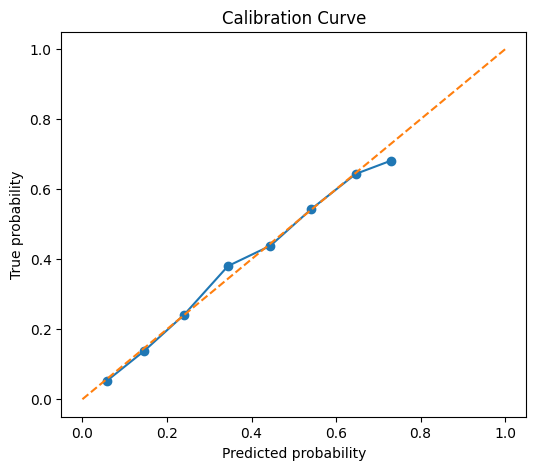

In [9]:
from sklearn.calibration import calibration_curve

# Get predicted probabilities
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.show()

SHAP value shape: (5000, 17)


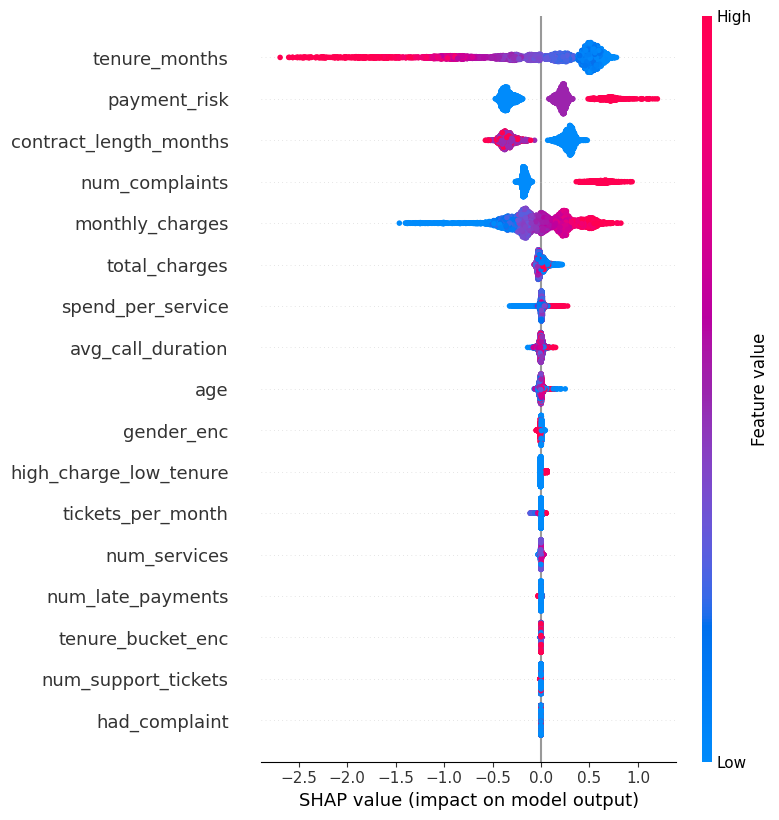

In [12]:
# ============================
# CELL 9 — GLOBAL SHAP SUMMARY
# ============================

import shap
import matplotlib.pyplot as plt

# Create TreeExplainer
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
raw_shap = explainer.shap_values(X_test)

# --- Handle different SHAP output structures ---
# Case 1: SHAP returns list (older versions of SHAP or multi-class models)
if isinstance(raw_shap, list):
    # Take class 1 (churn class)
    shap_values = raw_shap[1]
else:
    # Case 2: SHAP returns a single 2D ndarray → already correct
    shap_values = raw_shap

# Check shape to confirm it is 2D
print("SHAP value shape:", shap_values.shape)

# ============================
# Global SHAP Summary Plot
# ============================

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()

# Save the plot
plt.savefig("outputs/shap_summary_beeswarm.png", bbox_inches='tight')

# Show the plot
plt.show()


In [15]:
from sklearn.calibration import calibration_curve

# Get predicted probabilities
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

test_df = X_test.copy().reset_index(drop=True)
test_df['customer_id'] = idx_test.reset_index(drop=True)
test_df['y_true'] = y_test.reset_index(drop=True)
test_df['y_proba'] = y_pred_proba
test_df['y_pred'] = y_pred

churned = test_df[test_df['y_true']==1].sort_values('y_proba', ascending=False).head(3)
retained = test_df[test_df['y_true']==0].sort_values('y_proba', ascending=True).head(2)

selected = pd.concat([churned, retained]).reset_index(drop=True)
selected.to_csv("outputs/selected_customers_for_local_analysis.csv", index=False)

selected


,age,gender_enc,tenure_months,tenure_bucket_enc,monthly_charges,num_services,contract_length_months,avg_call_duration,num_complaints,num_support_tickets,...,total_charges,spend_per_service,high_charge_low_tenure,tickets_per_month,payment_risk,had_complaint,customer_id,y_true,y_proba,y_pred
0,64,1,8,2,93.96,1,1,10.75,2,0,...,882.86,93.960000,0,0.0,2,1,17671,1,0.797955,1
1,26,1,0,3,78.58,1,1,8.09,2,2,...,74.88,78.580000,1,2.0,2,1,5069,1,0.753452,1
2,67,0,0,3,75.42,2,1,14.08,1,0,...,72.04,37.710000,1,0.0,2,1,11414,1,0.752847,1
3,47,1,82,4,60.28,3,12,2.21,0,0,...,4650.80,20.093333,0,0.0,0,0,5448,0,0.014686,0
4,53,0,99,4,46.28,3,12,2.56,0,0,...,4952.60,15.426667,0,0.0,0,0,393,0,0.015515,0


In [22]:
# ============================================
# CELL 11 — FINAL, ERROR-PROOF LOCAL SHAP PLOTS
# ============================================

import shap
from IPython.display import display, HTML

# Load SHAP JS (must run before force_plot)
shap.initjs()

# --------------------------------------------
# 1. Resolve expected_value format (scalar/list)
# --------------------------------------------
if isinstance(explainer.expected_value, list):
    expected_val = explainer.expected_value[1]   # positive class
else:
    expected_val = explainer.expected_value      # scalar

# --------------------------------------------
# 2. Ensure SHAP values are 2D
# --------------------------------------------
shap_values_local = shap_values  # already fixed in Cell 9

# --------------------------------------------
# 3. Pick customer indices (3 churned, 2 retained)
# --------------------------------------------
churn_indices = y_test[y_test == 1].index[:3]
retain_indices = y_test[y_test == 0].index[:2]
selected_indices = list(churn_indices) + list(retain_indices)

print("Selected customer indices:", selected_indices)

# --------------------------------------------
# 4. Generate and Save HTML Force Plots
# --------------------------------------------
for idx in selected_indices:
    customer_id = f"customer_{idx}"

    # Convert index → integer location
    row_position = X_test.index.get_loc(idx)

    # Build force plot
    force_plot = shap.force_plot(
        expected_val,
        shap_values_local[row_position, :],
        X_test.loc[idx, :],
        matplotlib=False  # required for JS output
    )

    # Save as HTML (universal format)
    save_path = f"outputs/{customer_id}_force_plot.html"
    shap.save_html(save_path, force_plot)

    print(f"Saved: {save_path}")

    # Try to display plot (works only if JS allowed)
    try:
        display(force_plot)
    except:
        print("Force plot visualization suppressed (JS not supported here).")



Selected customer indices: [11593, 8896, 2147, 7151, 2650]
Saved: outputs/customer_11593_force_plot.html


Saved: outputs/customer_8896_force_plot.html


Saved: outputs/customer_2147_force_plot.html


Saved: outputs/customer_7151_force_plot.html


Saved: outputs/customer_2650_force_plot.html


In [23]:
report = f"""
INTERPRETABLE MACHINE LEARNING — Customer Churn SHAP Project

Feature Engineering Completed:
- tenure_bucket
- spend_per_service
- high_charge_low_tenure
- tickets_per_month
- payment_risk
- had_complaint
- contract_length_months
- categorical encodings (gender, contract, payment, tenure bucket)

Model Performance:
- AUC: {auc:.4f}
- F1-score: {f1:.4f}
- Brier score: {brier:.4f}

See outputs/ folder for:
- SHAP global summary plot
- SHAP feature importance CSV
- 5 SHAP force plots for selected customers
- Calibration curve
"""

with open("outputs/report_summary.txt", "w") as f:
    f.write(report)

report


'\nINTERPRETABLE MACHINE LEARNING — Customer Churn SHAP Project\n\nFeature Engineering Completed:\n- tenure_bucket\n- spend_per_service\n- high_charge_low_tenure\n- tickets_per_month\n- payment_risk\n- had_complaint\n- contract_length_months\n- categorical encodings (gender, contract, payment, tenure bucket)\n\nModel Performance:\n- AUC: 0.7608\n- F1-score: 0.2535\n- Brier score: 0.1418\n\nSee outputs/ folder for:\n- SHAP global summary plot\n- SHAP feature importance CSV\n- 5 SHAP force plots for selected customers\n- Calibration curve\n'